# Notebook 03 — Coalition Enumeration

**Purpose:** Enumerate every non-empty subset $S \subseteq \{F_1,\ldots,F_{15}\}$
(32 767 coalitions), solve a joint MILP for each one, and record the
characteristic function $v(S)$ — the maximum net surplus the coalition
can achieve together.

---
**Reads:**
- `data/processed/optimization_inputs.pkl`
- `data/processed/standalone_values.pkl`

**Writes:** `data/processed/characteristic_function.pkl`

---
### Coalition MILP (per coalition $S$)

**Decision variables per farmer $i \in S$:**
- `x[i,j]` ∈ {0,1} — does farmer $i$ adopt practice $j$?
- `z[i,j,k]` ∈ {0,1} for compatible pairs $j<k$ — linearisation of `x[i,j]·x[i,k]`

**Objective (maximise coalition net profit):**
$$
\max\;\sum_{i\in S}\Bigl[
  \mathrm{FS}_i\cdot\mathrm{CSP}_i(x_i)\cdot\mathrm{CCP}
  +\mathrm{YR}_i(x_i)
  -\mathrm{OC}_i(x_i)
\Bigr]
-C_{\mathrm{MRV}}(S)-C_T(S)
$$
where certification costs $C_{\mathrm{MRV}}(S)$ and $C_T(S)$ are constants
for a given $S$.

**Constraints:**
1. **Individual budget** (per farmer): $\mathrm{OC}_i(x_i) \leq B_i$
2. **Incompatibility** (per farmer): $x[i,j]+x[i,k]\leq 1$ for all $(j,k)$ with $\Delta_{jk}=1$
3. **Linearisation** (per farmer, per compatible pair)
4. **CF1 — pooled residual:**
   $\sum_{i\in S}\bigl(B_i - \mathrm{OC}_i(x_i)\bigr)\geq C_{\mathrm{MRV}}(S)+C_T(S)$

If the problem is infeasible, $v(S)=0$.
For $|S|=1$, $v(\{i\})$ must match $\tilde{v}(\{i\})$ from Notebook 02.

## 0. Imports and configuration

In [1]:
import sys
import pickle
import time
import warnings
from itertools import combinations
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB

# Progress bar — install with: pip install tqdm
from tqdm.auto import tqdm

# Parallelisation — install with: pip install joblib
from joblib import Parallel, delayed

sys.path.insert(0, str(Path.cwd()))
import config

Path(config.PROCESSED_DIR).mkdir(parents=True, exist_ok=True)



/Users/rohitsuresh/miniconda3/envs/pytorch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load inputs

In [3]:
# ── Optimization inputs ───────────────────────────────────────────────────────
with open(config.INPUTS_PKL, "rb") as f:
    inp = pickle.load(f)

farmers_df     = inp["farmers_15"]
practices_df   = inp["practices"]
practice_names = inp["practice_names"]
Alpha          = inp["Alpha"]
Beta           = inp["Beta"]
Gamma          = inp["Gamma"]
Delta          = inp["Delta"]
cfg            = inp["config"]

# ── Standalone values from Notebook 02 ───────────────────────────────────────
with open(config.STANDALONE_PKL, "rb") as f:
    standalone_values = pickle.load(f)

M  = len(practice_names)          # number of practices
N  = len(farmers_df)              # number of farmers

# Practice arrays ordered by practice_names
CSP_base = practices_df.set_index("Practice").reindex(practice_names)["Net_CSP_base"].values
OC_base  = practices_df.set_index("Practice").reindex(practice_names)["Net_OC_per_ha"].values
YLD_base = practices_df.set_index("Practice").reindex(practice_names)["Base_yield_change"].values

# Pair lists (built once, reused in every MILP)
compatible_pairs = [
    (j, k) for j in range(M) for k in range(j+1, M) if Delta[j, k] == 0
]
incompat_pairs = [
    (j, k) for j in range(M) for k in range(j+1, M) if Delta[j, k] == 1
]

print(f"Farmers          : {N}")
print(f"Practices        : {M}")
print(f"Compatible pairs : {len(compatible_pairs)}")
print(f"Incompatible pairs: {len(incompat_pairs)}")
print(f"Total coalitions : {2**N - 1:,}")

Farmers          : 15
Practices        : 20
Compatible pairs : 188
Incompatible pairs: 2
Total coalitions : 32,767


## 2. Pre-compute per-farmer static data

We build a compact lookup dict once here so the worker function receives
only what it needs — no redundant data copies.

In [4]:
# farmer_lookup[i] = (farmer_id, farm_size_ha, budget_INR)
farmer_ids = farmers_df["Farmer_ID"].tolist()

farmer_lookup: Dict[int, Tuple[str, float, float]] = {
    i: (
        farmers_df.iloc[i]["Farmer_ID"],
        float(farmers_df.iloc[i]["Farm_Size_ha"]),
        float(farmers_df.iloc[i]["Budget_total_INR_per_season"]),
    )
    for i in range(N)
}

# Pre-compute certification cost constants for every coalition size and area.
# These are fully determined by the set S, not by portfolio choices.
def coalition_cert_costs(s_indices: tuple) -> Tuple[float, float]:
    """
    Return (C_MRV, C_T) for the coalition identified by farmer indices.
    Both are constants that do not depend on the practice portfolio.
    """
    total_ha = sum(farmer_lookup[i][1] for i in s_indices)
    n_members = len(s_indices)
    c_mrv = cfg["FIXED_MRV"] + cfg["VARIABLE_MRV"] * (total_ha ** cfg["DELTA_MRV"])
    c_t   = cfg["FIXED_T"]   + cfg["VARIABLE_T"] * n_members
    return c_mrv, c_t

print("Farmer lookup built.")
print()
# Quick sanity: certification cost for the grand coalition
gc_cert = coalition_cert_costs(tuple(range(N)))
total_ha_gc = sum(farmer_lookup[i][1] for i in range(N))
print(f"Grand coalition ({N} farmers, {total_ha_gc:.2f} ha total):")
print(f"  C_MRV = {gc_cert[0]:,.0f} INR")
print(f"  C_T   = {gc_cert[1]:,.0f} INR")
print(f"  Total = {sum(gc_cert):,.0f} INR")

Farmer lookup built.

Grand coalition (15 farmers, 13.26 ha total):
  C_MRV = 17,213 INR
  C_T   = 9,500 INR
  Total = 26,713 INR


## 3. Coalition MILP solver

This function is called once per coalition.  It is designed to be safely
picklable so joblib can dispatch it to worker processes.

In [5]:
def solve_coalition(
    s_indices: tuple,
    # Static data — passed explicitly so the function is self-contained
    # and can be pickled cleanly by joblib.
    fl: dict,                    # farmer_lookup
    csp: np.ndarray,             # CSP_base
    oc: np.ndarray,              # OC_base
    yld: np.ndarray,             # YLD_base
    alpha: np.ndarray,
    beta: np.ndarray,
    gamma: np.ndarray,
    compat: list,                # compatible_pairs
    incompat: list,              # incompat_pairs
    m: int,                      # M
    cfg_snap: dict,
) -> Dict[str, Any]:
    """
    Solve the coalition MILP for the farmer set given by `s_indices`.

    Parameters
    ----------
    s_indices : tuple of int
        Indices into farmer_lookup identifying the coalition members.

    Returns
    -------
    dict with keys:
        s_indices          : tuple[int]
        status             : 'optimal' | 'infeasible' | 'other'
        v                  : float  — coalition value (0 if infeasible)
        portfolios         : dict[int, list[int]]  — farmer_idx -> adopted practice indices
                             Empty dict if infeasible.
        total_seq_tco2     : float
        total_oc_inr       : float
        total_yield_rev_inr: float
        total_carbon_rev_inr: float
        c_mrv              : float
        c_t                : float
        solve_time_s       : float
    """
    t0 = time.perf_counter()
    CCP   = cfg_snap["CCP"]
    PADDY = cfg_snap["PADDY_PRICE"]

    # ── Certification costs (constants for this coalition) ────────────────
    total_ha   = sum(fl[i][1] for i in s_indices)
    n_members  = len(s_indices)
    c_mrv = cfg_snap["FIXED_MRV"] + cfg_snap["VARIABLE_MRV"] * (total_ha ** cfg_snap["DELTA_MRV"])
    c_t   = cfg_snap["FIXED_T"]   + cfg_snap["VARIABLE_T"] * n_members
    cert_total = c_mrv + c_t

    # ── Early infeasibility: can the pooled budgets cover certification? ──
    # Even with OC=0 for everyone, CF1 requires sum(B_i) >= cert_total.
    budget_sum = sum(fl[i][2] for i in s_indices)
    if budget_sum < cert_total:
        return {
            "s_indices"           : s_indices,
            "status"              : "infeasible",
            "v"                   : 0.0,
            "portfolios"          : {},
            "total_seq_tco2"      : 0.0,
            "total_oc_inr"        : 0.0,
            "total_yield_rev_inr" : 0.0,
            "total_carbon_rev_inr": 0.0,
            "c_mrv"               : c_mrv,
            "c_t"                 : c_t,
            "solve_time_s"        : time.perf_counter() - t0,
        }

    # ── Build Gurobi model ────────────────────────────────────────────────
    env = gp.Env(empty=True)
    env.setParam("OutputFlag", 0)              # always silent in batch
    env.setParam("TimeLimit",  cfg_snap.get("GUROBI_TIME_LIMIT", 60))
    env.setParam("MIPGap",     cfg_snap.get("GUROBI_MIP_GAP", 1e-4))
    env.start()
    model = gp.Model(f"coal_{'_'.join(map(str, s_indices))}", env=env)
    model.setParam("OutputFlag", 0)

    # ── Decision variables ────────────────────────────────────────────────
    # x[i][j] ∈ {0,1}  — farmer i adopts practice j
    # z[i][(j,k)] ∈ {0,1} — linearisation of x[i][j]*x[i][k]
    #
    # Using Gurobi's tupledict for fast construction and lookup.
    x = {}
    z = {}
    for i in s_indices:
        x[i] = model.addVars(m, vtype=GRB.BINARY, name=f"x{i}")
        z[i] = model.addVars(compat, vtype=GRB.BINARY, name=f"z{i}")

    # ── Objective ─────────────────────────────────────────────────────────
    # For each farmer i: FS_i * [CSP_i(x_i)*CCP + YR_i(x_i) - OC_i(x_i)]
    # Certification costs are subtracted as constants.
    obj_terms = []
    for i in s_indices:
        FS = fl[i][1]
        # Linear terms (single-practice contributions)
        for j in range(m):
            coeff = FS * (
                csp[j] * CCP
                + yld[j] * PADDY
                - oc[j]
            )
            obj_terms.append(coeff * x[i][j])
        # Bilinear (linearised) terms — pairwise contributions
        for (j, k) in compat:
            coeff = FS * (
                alpha[j, k] * CCP
                + gamma[j, k] * PADDY
                - beta[j, k]
            )
            obj_terms.append(coeff * z[i][(j, k)])

    model.setObjective(
        gp.quicksum(obj_terms) - cert_total,
        GRB.MAXIMIZE
    )

    # ── Constraints ───────────────────────────────────────────────────────
    # We build the CF1 (pooled residual) expression incrementally
    # alongside the per-farmer constraints to avoid iterating twice.

    # OC expression for the entire coalition (for CF1)
    coalition_oc_expr = gp.LinExpr()

    for i in s_indices:
        FS = fl[i][1]
        B  = fl[i][2]

        # Per-farmer OC linear expression
        farmer_oc_expr = (
            gp.quicksum(FS * oc[j] * x[i][j] for j in range(m))
            + gp.quicksum(FS * beta[j, k] * z[i][(j, k)] for j, k in compat)
        )

        # Constraint 1: Individual budget  OC_i(x_i) ≤ B_i
        model.addConstr(
            farmer_oc_expr <= B,
            name=f"indiv_budget_{i}"
        )

        # Accumulate into coalition-wide OC for CF1
        coalition_oc_expr += farmer_oc_expr

        # Constraint 2: Incompatibility
        for j, k in incompat:
            model.addConstr(
                x[i][j] + x[i][k] <= 1,
                name=f"incompat_{i}_{j}_{k}"
            )

        # Constraint 3: Linearisation
        for j, k in compat:
            model.addConstr(z[i][(j, k)] <= x[i][j],             name=f"zub1_{i}_{j}_{k}")
            model.addConstr(z[i][(j, k)] <= x[i][k],             name=f"zub2_{i}_{j}_{k}")
            model.addConstr(z[i][(j, k)] >= x[i][j]+x[i][k]-1,  name=f"zlb_{i}_{j}_{k}")

    # Constraint 4: CF1 — pooled residual
    # Σ B_i - Σ OC_i(x_i) ≥ cert_total
    # ↔  Σ OC_i(x_i) ≤ budget_sum - cert_total
    model.addConstr(
        coalition_oc_expr <= budget_sum - cert_total,
        name="CF1_pooled_residual"
    )

    # ── Solve ─────────────────────────────────────────────────────────────
    model.optimize()
    status = model.Status

    # ── Extract results ───────────────────────────────────────────────────
    if status == GRB.OPTIMAL:
        portfolios = {}
        total_seq = 0.0
        total_oc  = 0.0
        total_yr  = 0.0

        for i in s_indices:
            FS = fl[i][1]
            x_vals = {j: round(x[i][j].X) for j in range(m)}
            z_vals = {(j, k): round(z[i][(j, k)].X) for j, k in compat}

            adopted = [j for j in range(m) if x_vals[j] == 1]
            portfolios[i] = adopted

            # Recompute from solution for reporting
            seq_i = FS * (
                sum(csp[j]         for j in adopted)
                + sum(alpha[j, k] * z_vals[(j, k)] for j, k in compat)
            )
            oc_i = FS * (
                sum(oc[j]          for j in adopted)
                + sum(beta[j, k]  * z_vals[(j, k)] for j, k in compat)
            )
            yr_i = FS * PADDY * (
                sum(yld[j]         for j in adopted)
                + sum(gamma[j, k] * z_vals[(j, k)] for j, k in compat)
            )
            total_seq += seq_i
            total_oc  += oc_i
            total_yr  += yr_i

        v_val        = model.ObjVal
        carbon_rev   = total_seq * CCP
        result_status = "optimal"

    else:
        v_val        = 0.0
        portfolios   = {}
        total_seq    = 0.0
        total_oc     = 0.0
        total_yr     = 0.0
        carbon_rev   = 0.0
        result_status = "infeasible" if status == GRB.INFEASIBLE else f"status_{status}"

    model.dispose()
    env.dispose()

    return {
        "s_indices"            : s_indices,
        "status"               : result_status,
        "v"                    : v_val,
        "portfolios"           : portfolios,   # {farmer_idx: [practice_idx,...]}
        "total_seq_tco2"       : total_seq,
        "total_oc_inr"         : total_oc,
        "total_yield_rev_inr"  : total_yr,
        "total_carbon_rev_inr" : carbon_rev,
        "c_mrv"                : c_mrv,
        "c_t"                  : c_t,
        "solve_time_s"         : time.perf_counter() - t0,
    }

## 4. Generate all coalitions

We enumerate by coalition size (1, 2, …, N) so singletons are solved first,
letting us verify them against Notebook 02 before committing to the full run.

In [6]:
all_coalitions: List[tuple] = []
for size in range(1, N + 1):
    all_coalitions.extend(combinations(range(N), size))

# Convert each combination to a tuple (already is, but be explicit)
all_coalitions = [tuple(c) for c in all_coalitions]

print(f"Total coalitions to solve: {len(all_coalitions):,}")
print(f"  Singletons  : {N}")
print(f"  Pairs       : {N*(N-1)//2}")
print(f"  Grand coal. : 1  (last in list)")
print(f"  All others  : {len(all_coalitions) - N - N*(N-1)//2 - 1}")

Total coalitions to solve: 32,767
  Singletons  : 15
  Pairs       : 105
  Grand coal. : 1  (last in list)
  All others  : 32646


## 5. Run singleton solves first — verify against Notebook 02

Before launching the full parallel sweep, we solve the 15 singletons
sequentially and cross-check against `standalone_values` from Notebook 02.
This validates the coalition solver at zero cost.

In [ ]:

static = dict(
    fl       = farmer_lookup,
    csp      = CSP_base,
    oc       = OC_base,
    yld      = YLD_base,
    alpha    = Alpha,
    beta     = Beta,
    gamma    = Gamma,
    compat   = compatible_pairs,
    incompat = incompat_pairs,
    m        = M,
    cfg_snap = {
        **cfg,
        "GUROBI_TIME_LIMIT": config.GUROBI_TIME_LIMIT,
        "GUROBI_MIP_GAP"   : config.GUROBI_MIP_GAP,
    },
)

print("Solving singletons...")
singleton_results: Dict[str, Dict] = {}
TOLERANCE = 5.0   # INR — allowable mismatch between NB02 and NB03 singleton values

all_match = True
print(f"{'Farmer':<8}  {'NB02 ṽ':>12}  {'NB03 v':>12}  {'Diff':>10}  Status")
print("-" * 60)

for i in range(N):
    res = solve_coalition((i,), **static)
    fid = farmer_lookup[i][0]
    singleton_results[fid] = res

    v_nb03 = res["v"]
    v_nb02 = standalone_values[fid]["standalone_value"]
    diff   = abs(v_nb03 - v_nb02)

    match  = diff <= TOLERANCE
    if not match:
        all_match = False
    flag = "OK" if match else "MISMATCH ← investigate"

    print(f"{fid:<8}  {v_nb02:>12,.0f}  {v_nb03:>12,.0f}  {diff:>10.2f}  {flag}")

print()
if all_match:
    print("Singleton verification: ALL PASS ✓")
else:
    print("WARNING: Some singletons do not match NB02 standalone values.")
    print("Investigate sign conventions or budget constraint differences before proceeding.")

Solving singletons...
Farmer          NB02 ṽ        NB03 v        Diff  Status
------------------------------------------------------------
F0001                0             0        0.00  OK
F0002                0             0        0.00  OK
F0003                0             0        0.00  OK
F0004                0             0        0.00  OK
F0005                0             0        0.00  OK
F0006                0             0        0.00  OK
F0007                0             0        0.00  OK
F0008                0             0        0.00  OK
F0009                0             0        0.00  OK
F0010                0             0        0.00  OK
F0011                0             0        0.00  OK
F0012                0             0        0.00  OK
F0013                0             0        0.00  OK
F0014                0             0        0.00  OK
F0015                0             0        0.00  OK

Singleton verification: ALL PASS ✓


## 6. Full enumeration — parallel MILP sweep

We skip singletons here (already solved above) and solve the remaining
$2^{15} - 15 - 1 = 32{,}752$ coalitions in parallel.

> **Gurobi licence note:** By default Gurobi permits multiple simultaneous
> solver instances.  If you see licence errors, set `N_JOBS = 1` in
> `config.py` to fall back to sequential execution.

In [8]:
# Singletons are done; solve everything else (pairs through grand coalition)
non_singleton_coalitions = [c for c in all_coalitions if len(c) > 1]

print(f"Coalitions remaining  : {len(non_singleton_coalitions):,}")
print(f"Parallel workers      : {config.N_JOBS}  (-1 = all CPU cores)")
print()
print("Starting parallel enumeration...")

t_start = time.perf_counter()

try:
    raw_results = Parallel(
        n_jobs      = config.N_JOBS,
        backend     = "loky",
        verbose     = 0,
        batch_size  = "auto",
    )(
        delayed(solve_coalition)(s, **static)
        for s in tqdm(
            non_singleton_coalitions,
            desc        = "Solving coalitions",
            unit        = "coal.",
            smoothing   = 0.05,
            miniters    = 100,
        )
    )
    print("\nParallel run completed.")

except Exception as exc:
    warnings.warn(
        f"Parallel execution failed ({exc}). "
        "Falling back to sequential solve. This will be slower."
    )
    raw_results = []
    for s in tqdm(non_singleton_coalitions, desc="Solving (sequential)", unit="coal."):
        raw_results.append(solve_coalition(s, **static))

t_elapsed = time.perf_counter() - t_start
print(f"Elapsed: {t_elapsed:.1f} s  ({t_elapsed/60:.1f} min)")

Coalitions remaining  : 32,752
Parallel workers      : -1  (-1 = all CPU cores)

Starting parallel enumeration...


Solving coalitions: 100%|██████████| 32752/32752 [06:41<00:00, 81.57coal./s] 



Parallel run completed.
Elapsed: 402.0 s  (6.7 min)


## 7. Assemble the characteristic function

In [9]:
# characteristic_function maps frozenset of Farmer_IDs to coalition value v(S)
characteristic_function: Dict[frozenset, float] = {}

# Also store: status and sequestration for every coalition (compact)
coalition_meta: Dict[frozenset, Dict] = {}

# ── Insert singletons from Step 5 ────────────────────────────────────────────
for i in range(N):
    fid = farmer_lookup[i][0]
    res = singleton_results[fid]
    key = frozenset([fid])
    characteristic_function[key] = res["v"]
    coalition_meta[key] = {
        "status"       : res["status"],
        "seq_tco2"     : res["total_seq_tco2"],
        "n_farmers"    : 1,
        "total_ha"     : farmer_lookup[i][1],
        "solve_time_s" : res["solve_time_s"],
    }

# ── Insert all other coalitions from parallel results ────────────────────────
grand_coalition_result = None
grand_coalition_key    = frozenset(farmer_ids)

for res in raw_results:
    s_idx = res["s_indices"]
    key   = frozenset(farmer_lookup[i][0] for i in s_idx)
    characteristic_function[key] = res["v"]
    coalition_meta[key] = {
        "status"       : res["status"],
        "seq_tco2"     : res["total_seq_tco2"],
        "n_farmers"    : len(s_idx),
        "total_ha"     : sum(farmer_lookup[i][1] for i in s_idx),
        "solve_time_s" : res["solve_time_s"],
    }
    if key == grand_coalition_key:
        grand_coalition_result = res

print(f"Characteristic function entries : {len(characteristic_function):,}")
print(f"Expected                        : {2**N - 1:,}")
assert len(characteristic_function) == 2**N - 1, "Entry count mismatch!"
print("Entry count: PASS ✓")

Characteristic function entries : 32,767
Expected                        : 32,767
Entry count: PASS ✓


## 8. Grand coalition details

In [10]:
v_gc = characteristic_function[grand_coalition_key]
gc_meta = coalition_meta[grand_coalition_key]

print("=" * 60)
print("GRAND COALITION")
print("=" * 60)
print(f"  Farmers          : {N}")
print(f"  Total area (ha)  : {gc_meta['total_ha']:.2f}")
print(f"  Status           : {gc_meta['status']}")
print(f"  v(Grand)  (INR)  : {v_gc:>15,.0f}")
print(f"  Seq. (tCO2/seas) : {gc_meta['seq_tco2']:>10.2f}")

# Compare with sum of standalone values
sum_sv = sum(standalone_values[fid]["standalone_value"] for fid in farmer_ids)
surplus = v_gc - sum_sv
print()
print(f"  Σ ṽ({{i}})  (INR) : {sum_sv:>15,.0f}")
print(f"  Coalition surplus: {surplus:>15,.0f}  "
      f"({'+' if surplus>=0 else ''}{100*surplus/max(sum_sv,1):.1f}% over sum of solo)")

# Grand coalition portfolios
print()
print("Optimal portfolios in grand coalition:")
print("-" * 60)
if grand_coalition_result and grand_coalition_result["portfolios"]:
    for i in range(N):
        fid   = farmer_lookup[i][0]
        port  = grand_coalition_result["portfolios"].get(i, [])
        pnames = [practice_names[j] for j in port]
        print(f"  {fid} ({farmer_lookup[i][1]:.2f} ha): {len(port)} practices")
        for pn in pnames:
            print(f"      • {pn}")
else:
    print("  Grand coalition was infeasible — no portfolios available.")

GRAND COALITION
  Farmers          : 15
  Total area (ha)  : 13.26
  Status           : optimal
  v(Grand)  (INR)  :       1,499,422
  Seq. (tCO2/seas) :     199.54

  Σ ṽ({i})  (INR) :               0
  Coalition surplus:       1,499,422  (+149942168.5% over sum of solo)

Optimal portfolios in grand coalition:
------------------------------------------------------------
  F0001 (0.82 ha): 18 practices
      • Zero Tillage (ZT)
      • Crop Residue Retention
      • Reduced / Minimum Tillage
      • Puddling Reduction
      • Mid-Season Drainage (MSD)
      • Alternate Wetting and Drying (AWD)
      • System of Rice Intensification (SRI) Water Management
      • Optimised / Variable-Rate N Application
      • Integrated Nutrient Management (INM) – Organic + Inorganic
      • Green Manure Incorporation
      • Farmyard Manure (FYM) Application
      • Compost Application
      • Biochar Application
      • Rice Straw Incorporation with N Fertiliser
      • Crop Rotation and Diversificat

## 9. Characteristic function analysis

In [11]:
# ── 9a. Value distribution by coalition size ──────────────────────────────────
size_stats: Dict[int, list] = {k: [] for k in range(1, N+1)}
n_feasible_by_size: Dict[int, int] = {k: 0 for k in range(1, N+1)}

for key, v in characteristic_function.items():
    sz = len(key)
    size_stats[sz].append(v)
    if coalition_meta[key]["status"] == "optimal":
        n_feasible_by_size[sz] += 1

print(f"{'Size':>5}  {'Count':>7}  {'Feasible':>9}  "
      f"{'Min v':>12}  {'Median v':>12}  {'Max v':>12}  {'Mean v':>12}")
print("-" * 80)
for sz in range(1, N+1):
    vals = np.array(size_stats[sz])
    print(
        f"{sz:>5}  {len(vals):>7,}  {n_feasible_by_size[sz]:>9,}  "
        f"{vals.min():>12,.0f}  {np.median(vals):>12,.0f}  "
        f"{vals.max():>12,.0f}  {vals.mean():>12,.0f}"
    )

 Size    Count   Feasible         Min v      Median v         Max v        Mean v
--------------------------------------------------------------------------------
    1       15          0             0             0             0             0
    2      105          0             0             0             0             0
    3      455         32             0             0       547,088        32,972
    4    1,365        330             0             0       697,404       126,735
    5    3,003      1,479             0             0       843,216       285,980
    6    5,005      3,682             0       593,566       953,628       473,231
    7    6,435      5,793             0       694,761     1,053,770       644,751
    8    6,435      6,285             0       794,844     1,147,066       782,548
    9    5,005      4,997             0       896,097     1,225,503       894,745
   10    3,003      3,003       646,409       997,372     1,299,372       996,239
   11    1,365   

In [12]:
# ── 9b. Superadditivity check ─────────────────────────────────────────────────
# v(S ∪ T) ≥ v(S) + v(T) for all disjoint S, T
# We check a random sample of disjoint pairs to avoid O(4^N) enumeration.

rng = np.random.default_rng(42)
N_CHECK = min(5000, len(all_coalitions) // 2)

violations = 0
checks_done = 0

# Build index: size -> list of frozensets of that size
by_size: Dict[int, list] = {sz: [] for sz in range(1, N+1)}
for key in characteristic_function:
    by_size[len(key)].append(key)

# Sample pairs: pick a random coalition S, then a random disjoint coalition T
all_keys = list(characteristic_function.keys())
for _ in range(N_CHECK):
    idx_s = rng.integers(0, len(all_keys))
    S = all_keys[idx_s]
    remaining = [k for k in all_keys if k.isdisjoint(S)]
    if not remaining:
        continue
    idx_t = rng.integers(0, len(remaining))
    T = remaining[idx_t]
    ST = S | T
    if ST not in characteristic_function:
        continue
    checks_done += 1
    if characteristic_function[ST] < characteristic_function[S] + characteristic_function[T] - 1.0:
        violations += 1

print(f"Superadditivity check (random sample of {checks_done:,} disjoint pairs):")
if violations == 0:
    print(f"  Violations: 0 — game is superadditive (PASS ✓)")
else:
    pct = 100 * violations / max(checks_done, 1)
    print(f"  Violations: {violations} ({pct:.1f}%)")
    print("  NOTE: Some violations may reflect infeasible sub-coalitions (v=0).")
    print("  Check if violations occur only when v(S)=0 or v(T)=0.")

Superadditivity check (random sample of 5,000 disjoint pairs):
  Violations: 0 — game is superadditive (PASS ✓)


In [13]:
# ── 9c. Summary statistics ────────────────────────────────────────────────────
all_values = np.array(list(characteristic_function.values()))
n_positive = (all_values > 0).sum()
n_zero     = (all_values == 0).sum()
n_negative = (all_values < 0).sum()

print("Overall characteristic function statistics")
print("-" * 45)
print(f"  Total coalitions   : {len(all_values):,}")
print(f"  v > 0 (profitable) : {n_positive:,}  ({100*n_positive/len(all_values):.1f}%)")
print(f"  v = 0 (infeasible) : {n_zero:,}  ({100*n_zero/len(all_values):.1f}%)")
print(f"  v < 0 (loss)       : {n_negative:,}  ({100*n_negative/len(all_values):.1f}%)")
print()
pos_vals = all_values[all_values > 0]
if len(pos_vals) > 0:
    print(f"  Among profitable coalitions:")
    print(f"    Min   : {pos_vals.min():>12,.0f} INR")
    print(f"    Median: {np.median(pos_vals):>12,.0f} INR")
    print(f"    Mean  : {pos_vals.mean():>12,.0f} INR")
    print(f"    Max   : {pos_vals.max():>12,.0f} INR")

Overall characteristic function statistics
---------------------------------------------
  Total coalitions   : 32,767
  v > 0 (profitable) : 27,542  (84.1%)
  v = 0 (infeasible) : 5,225  (15.9%)
  v < 0 (loss)       : 0  (0.0%)

  Among profitable coalitions:
    Min   :      418,054 INR
    Median:      791,415 INR
    Mean  :      808,609 INR
    Max   :    1,499,422 INR


## 10. Visualisations

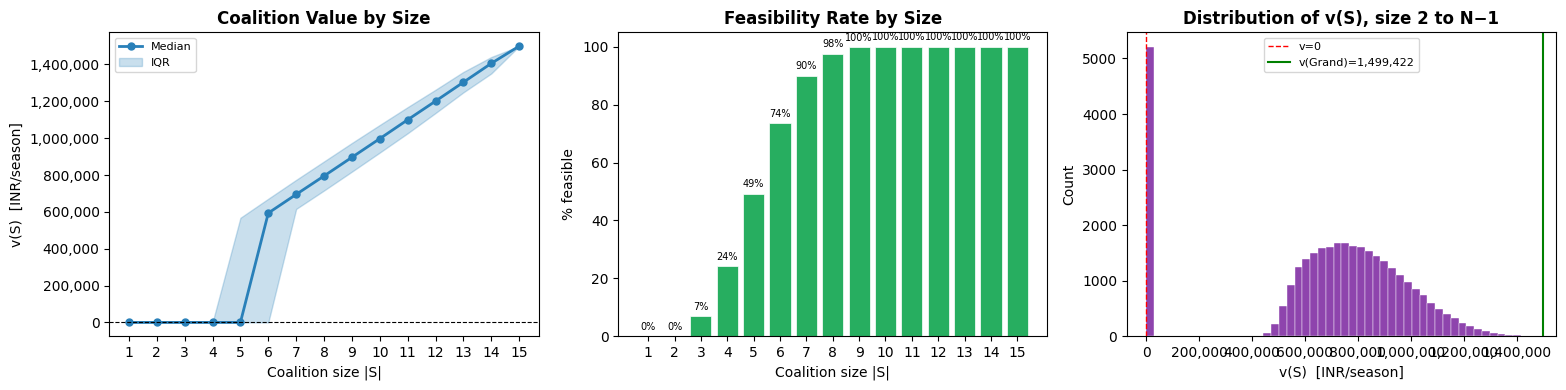

Figure saved.


In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot 1: Median coalition value by size ────────────────────────────────────
ax = axes[0]
sizes    = list(range(1, N+1))
medians  = [np.median(size_stats[sz]) for sz in sizes]
q25      = [np.percentile(size_stats[sz], 25) for sz in sizes]
q75      = [np.percentile(size_stats[sz], 75) for sz in sizes]

ax.plot(sizes, medians, "o-", color="#2980b9", linewidth=2, markersize=5, label="Median")
ax.fill_between(sizes, q25, q75, alpha=0.25, color="#2980b9", label="IQR")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Coalition Value by Size", fontweight="bold")
ax.set_xlabel("Coalition size |S|")
ax.set_ylabel("v(S)  [INR/season]")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=8)
ax.set_xticks(sizes)

# ── Plot 2: Feasibility rate by coalition size ────────────────────────────────
ax = axes[1]
n_total_by_size = [len(size_stats[sz]) for sz in sizes]
feas_rate = [
    100 * n_feasible_by_size[sz] / max(n_total_by_size[sz-1], 1)
    for sz in sizes
]
ax.bar(sizes, feas_rate, color="#27ae60", edgecolor="white", linewidth=0.5)
ax.set_title("Feasibility Rate by Size", fontweight="bold")
ax.set_xlabel("Coalition size |S|")
ax.set_ylabel("% feasible")
ax.set_ylim(0, 105)
ax.set_xticks(sizes)
for sz, fr in zip(sizes, feas_rate):
    ax.text(sz, fr + 1.5, f"{fr:.0f}%", ha="center", va="bottom", fontsize=7)

# ── Plot 3: Distribution of v(S) for coalitions of size 2–(N-1) ──────────────
ax = axes[2]
mid_vals = [
    v for key, v in characteristic_function.items()
    if 2 <= len(key) <= N-1
]
ax.hist(mid_vals, bins=50, color="#8e44ad", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="red",  linewidth=1, linestyle="--", label="v=0")
ax.axvline(v_gc, color="green", linewidth=1.5, linestyle="-", label=f"v(Grand)={v_gc:,.0f}")
ax.set_title("Distribution of v(S), size 2 to N−1", fontweight="bold")
ax.set_xlabel("v(S)  [INR/season]")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{config.PROCESSED_DIR}/nb03_coalition_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 11. Save characteristic function pickle

In [15]:
# Extract grand coalition portfolios (keyed by Farmer_ID, not index)
grand_coalition_portfolios: Dict[str, List[int]] = {}
if grand_coalition_result and grand_coalition_result["portfolios"]:
    for i, port in grand_coalition_result["portfolios"].items():
        fid = farmer_lookup[i][0]
        grand_coalition_portfolios[fid] = port

# Solve statistics
all_times  = (
    [singleton_results[fid]["solve_time_s"] for fid in farmer_ids]
    + [r["solve_time_s"] for r in raw_results]
)
solve_stats = {
    "total_coalitions"  : len(characteristic_function),
    "n_optimal"         : sum(1 for m in coalition_meta.values() if m["status"] == "optimal"),
    "n_infeasible"      : sum(1 for m in coalition_meta.values() if m["status"] != "optimal"),
    "total_solve_time_s": sum(all_times),
    "mean_solve_time_s" : float(np.mean(all_times)),
    "max_solve_time_s"  : float(np.max(all_times)),
}

output_dict = {
    # Core deliverable: v(S) for every coalition
    "characteristic_function"   : characteristic_function,

    # Grand coalition info needed by NB04
    "grand_coalition_key"       : grand_coalition_key,
    "grand_coalition_value"     : v_gc,
    "grand_coalition_portfolios": grand_coalition_portfolios,   # fid -> [practice_idx]

    # Ordered farmer info (needed to interpret index-keyed portfolios)
    "farmer_ids"                : farmer_ids,
    "practice_names"            : practice_names,

    # Per-coalition metadata (status, seq, area) — compact
    "coalition_meta"            : coalition_meta,

    # Diagnostics
    "solve_stats"               : solve_stats,
}

out_path = Path(config.CHARACTERISTIC_FN_PKL)
with open(out_path, "wb") as f:
    pickle.dump(output_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

file_size_mb = out_path.stat().st_size / (1024**2)
print(f"Saved: {out_path.resolve()}")
print(f"File size: {file_size_mb:.2f} MB")
print()
print("Solve statistics:")
for k, v in solve_stats.items():
    print(f"  {k:<25}: {v}")

Saved: /Users/rohitsuresh/Desktop/CGT_Carbon_farming/data/processed/characteristic_function.pkl
File size: 3.46 MB

Solve statistics:
  total_coalitions         : 32767
  n_optimal                : 27542
  n_infeasible             : 5225
  total_solve_time_s       : 3976.570311841555
  mean_solve_time_s        : 0.1213589987439056
  max_solve_time_s         : 1.1399746658280492


## 12. Reload and verify

In [16]:
with open(config.CHARACTERISTIC_FN_PKL, "rb") as f:
    loaded = pickle.load(f)

cf_loaded = loaded["characteristic_function"]

assert len(cf_loaded) == 2**N - 1, "Entry count mismatch after reload"
assert abs(loaded["grand_coalition_value"] - v_gc) < 1.0, "Grand coalition value mismatch"

# Spot-check 100 random entries
sample_keys = list(cf_loaded.keys())[:100]
for key in sample_keys:
    assert abs(cf_loaded[key] - characteristic_function[key]) < 1e-6, \
        f"Value mismatch for coalition {key}"

print("Pickle reload checks: all PASS ✓")
print()
print("=" * 55)
print("NOTEBOOK 03 COMPLETE")
print("=" * 55)
print(f"  Coalitions solved   : {len(characteristic_function):,}")
print(f"  v(Grand coalition)  : {v_gc:,.0f} INR")
print(f"  Output              : {config.CHARACTERISTIC_FN_PKL}")
print()
print("Ready for Notebook 04 — Surplus Allocation")

Pickle reload checks: all PASS ✓

NOTEBOOK 03 COMPLETE
  Coalitions solved   : 32,767
  v(Grand coalition)  : 1,499,422 INR
  Output              : /Users/rohitsuresh/Desktop/CGT_Carbon_farming/data/processed/characteristic_function.pkl

Ready for Notebook 04 — Surplus Allocation
